# Exercise 4: Blast Off!

In [138]:
%%writefile blastoff.py

import numpy as np
import matplotlib.pyplot as plt
import sys

def parse_apollo(filename):

    data = {}  # dictionary for data arrays
    units = {}  # dictionary for units
    headings = None
    find_units = None

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("$") or line == "":
                continue # ignore

            # Creating lists to store each columns data
            if line.startswith("TIME"):
                headings = [i.strip() for i in line.split(",")]
                find_units = True
                continue

            # storing units for each columns
            
            if find_units:
                u_list = [u.strip() for u in line.split(",")]
                for i in range(len(headings)):
                    units[headings[i]] = u_list[i]

                for h in headings:
                    data[h] = []

                find_units = False 
                continue

            # Appedning each value to correct column
            if headings and "," in line:
                parts = [i.strip() for i in line.split(",")]
                if len(parts) == len(headings):
                    try:
                        # converting to floats
                        nums = list(map(float, parts))
                        for i in range(len(headings)):
                            column = headings[i]
                            value = nums[i]
                            data[column].append(value)
                    except ValueError:
                        #skipping rows without numeric data
                        pass

    # converting data
    for h in data:
        data[h] = np.array(data[h])

    return data, units

def plot_parameters(data, units):
    time = data['TIME']
    for key in data:
        if key == 'TIME':
            continue
        plt.figure(figsize=(10,5))
        plt.plot(time, data[key])
        plt.xlabel("Time (s)")
        plt.ylabel(f'{key} ({units[key]})')
        plt.title(f"{key} vs Time")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def groundtrack(data, units):
    plt.figure(figsize=(10,5))
    plt.plot(data['LONG'], data['GC LAT'])
    plt.xlabel(f"Longitude ({units['LONG']})")
    plt.ylabel(f'Latitude ({units['GC LAT']})')
    plt.title('Apollo 10 Ground Track')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def groundtrack_map(data, units, altitude = False):
    def plot_map(im, extent, title):
        fig, ax = plt.subplots(figsize=(10,5))
        ax.set_aspect("equal")
        plt.imshow(plt.imread(im), extent=extent)
        if altitude:
            plot = plt.scatter(data['LONG'], data['GC LAT'], c=data['ALTITUDE'], cmap='inferno')
            plt.colorbar(plot, label= f'Altitude ({units['ALTITUDE']})')
        else:
            plt.scatter(data['LONG'], data['GC LAT'], color='black')
        plt.xlabel(f"Longitude ({units['LONG']})")
        plt.ylabel(f'Latitude ({units['GC LAT']})')
        plt.title(title)
        plt.tight_layout()

    plot_map(r'maps\NE1_50M_SR_W_1080.png', [-180, 180, -90, 90], 'Ground Track on World Map')
    plot_map(r'maps\NE1_50M_SR_W_CROPPED_1080.png', [-120, -30, 15, 60], 'Ground Track on Cropped Map')

def main(file):
    data, units = parse_apollo(file)
    plot_parameters(data, units)
    groundtrack(data, units)
    groundtrack_map(data, units)
    groundtrack_map(data, units, True)

if __name__ == '__main__':
    args = sys.argv[1:]
    main(args[0])


Overwriting blastoff.py


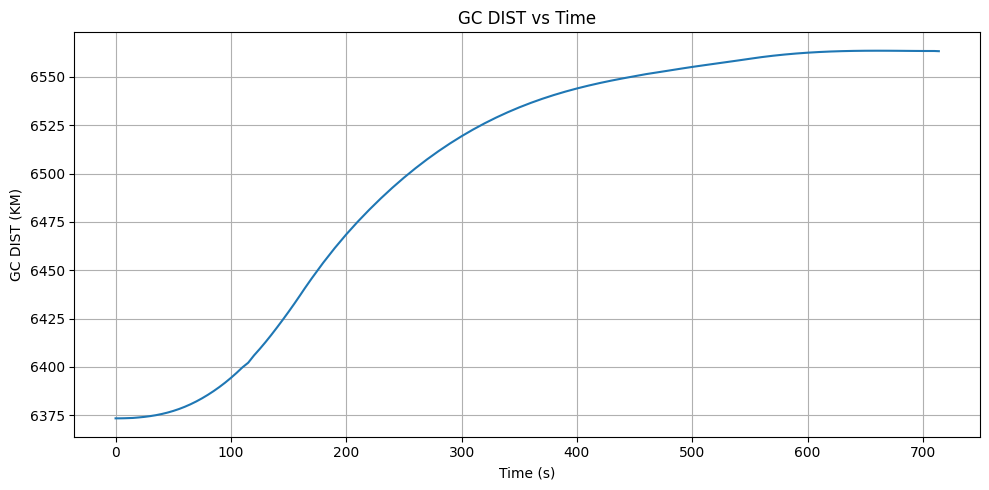

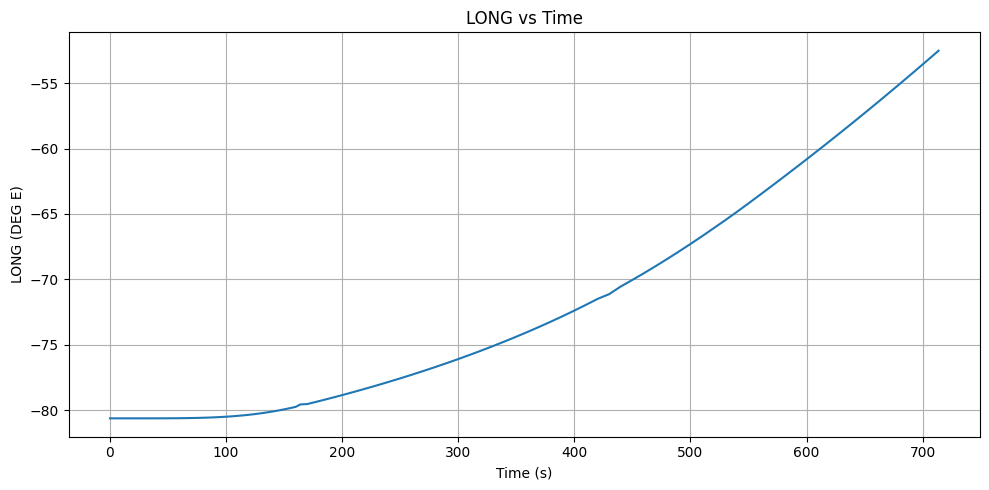

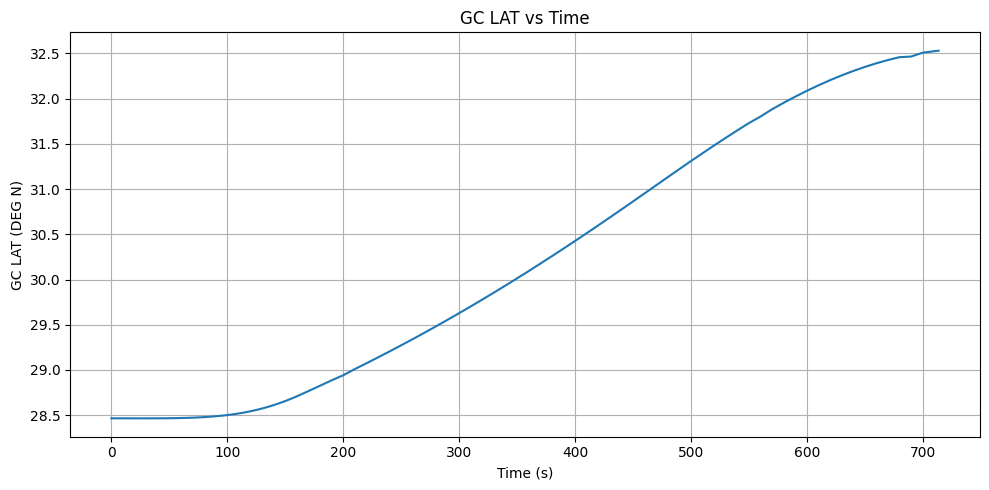

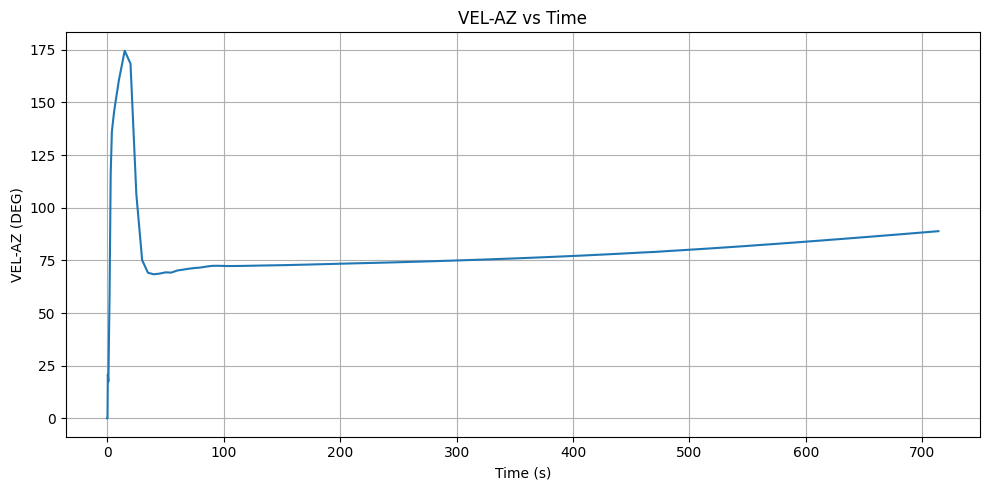

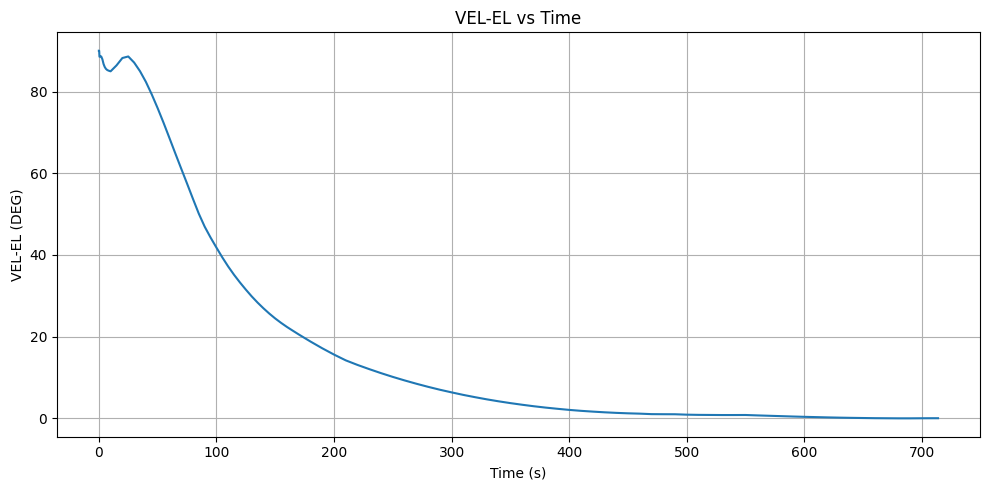

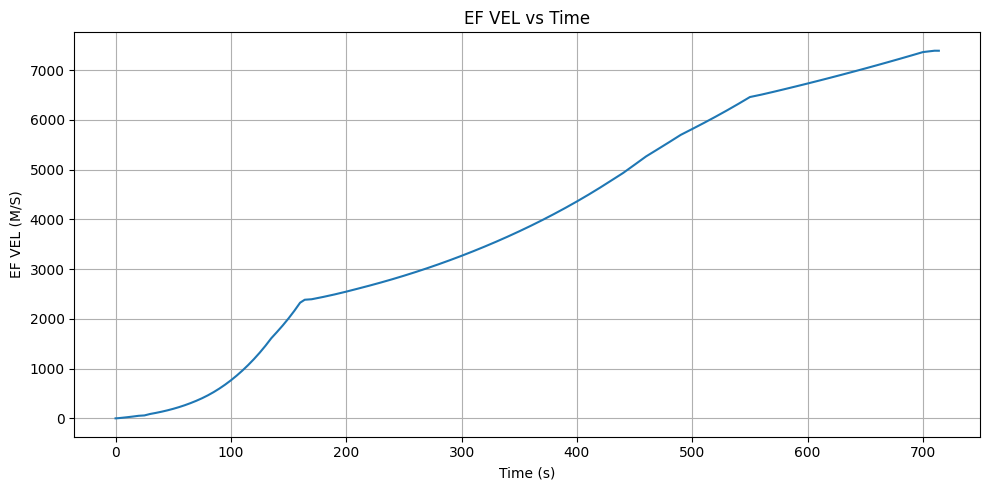

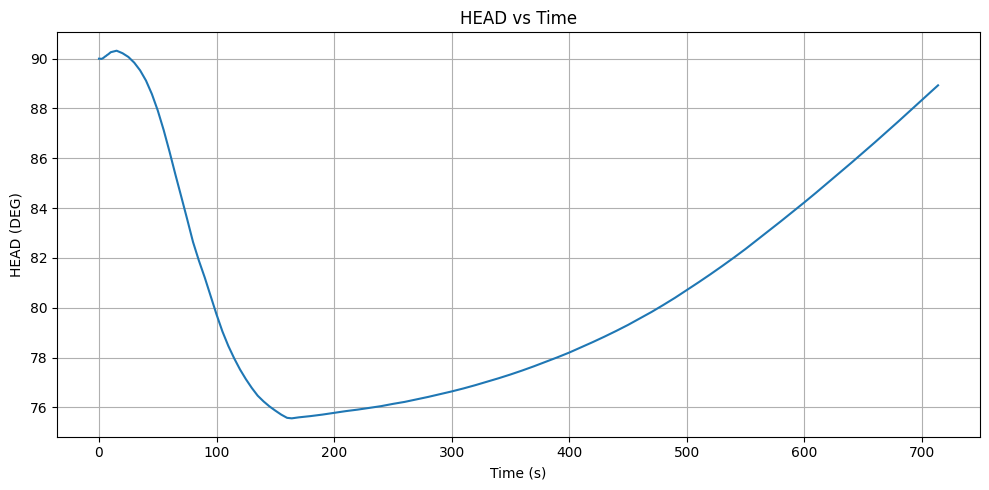

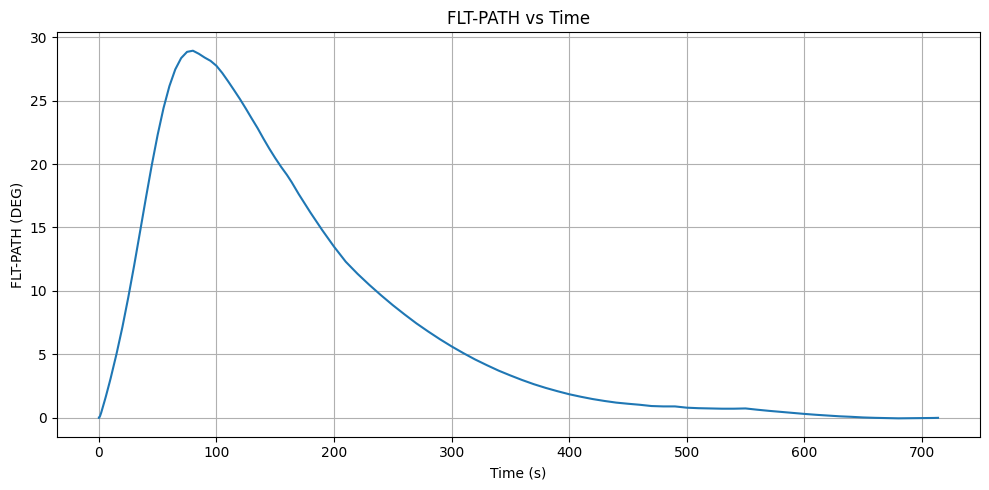

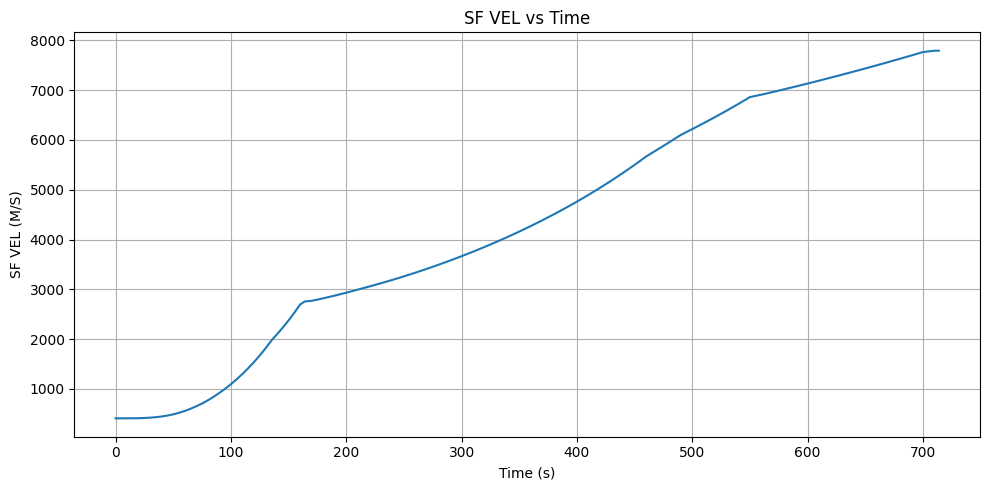

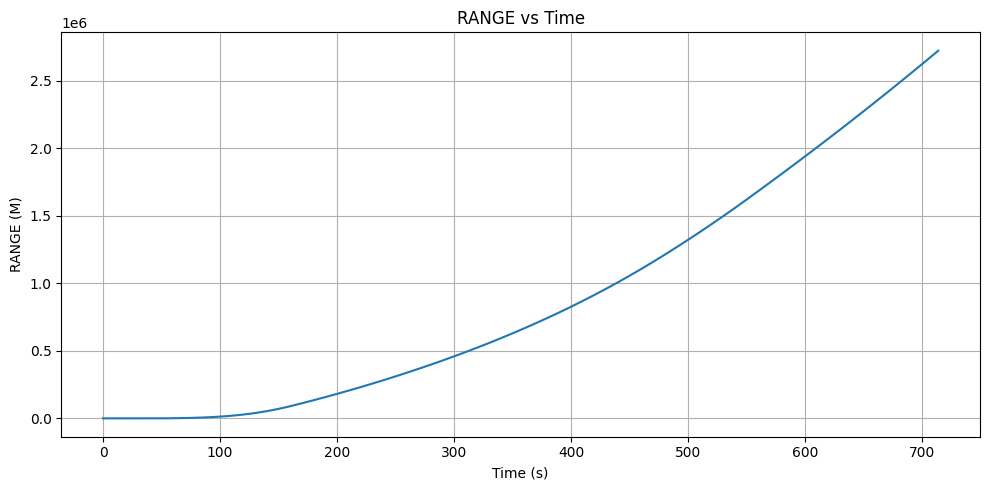

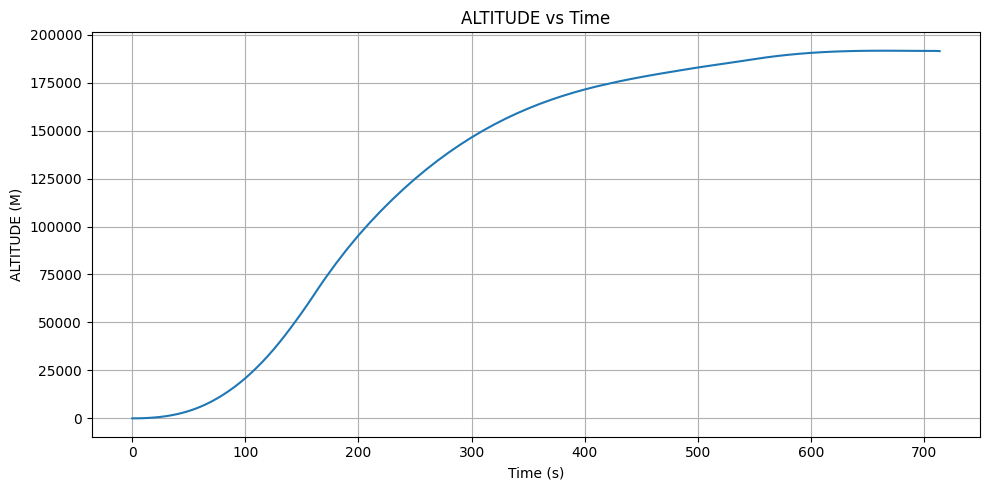

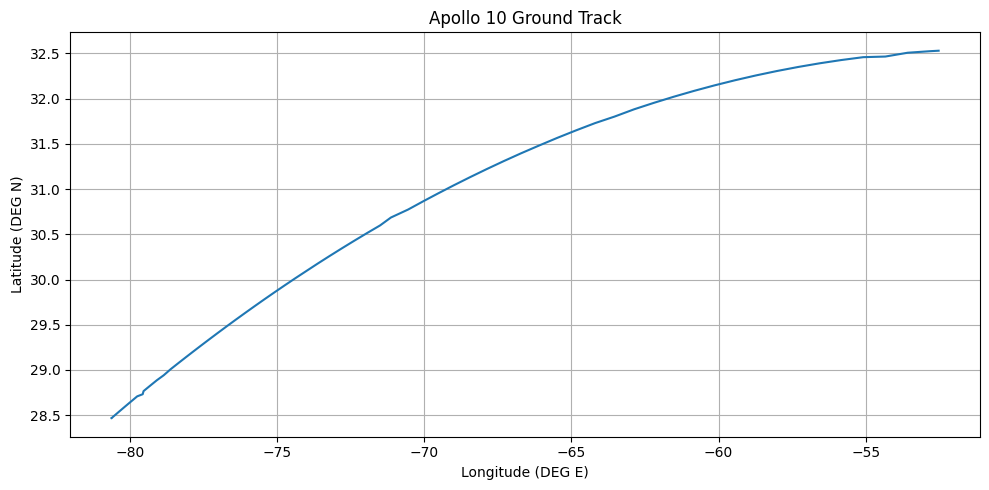

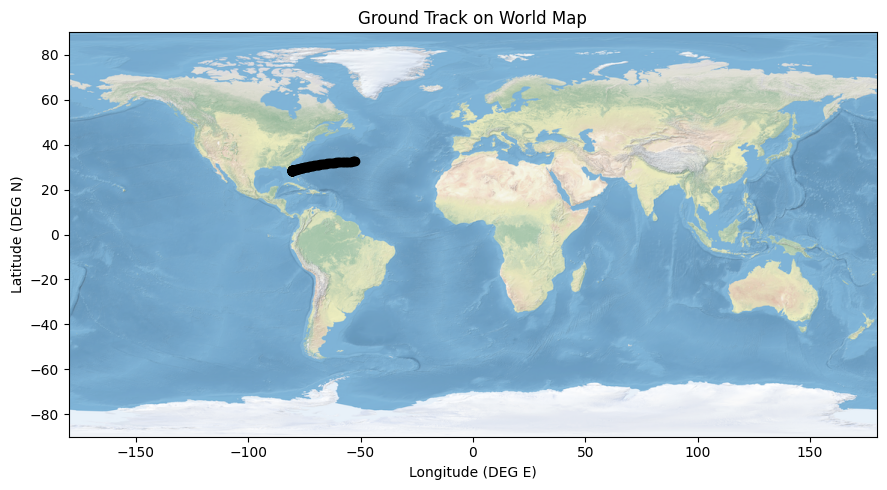

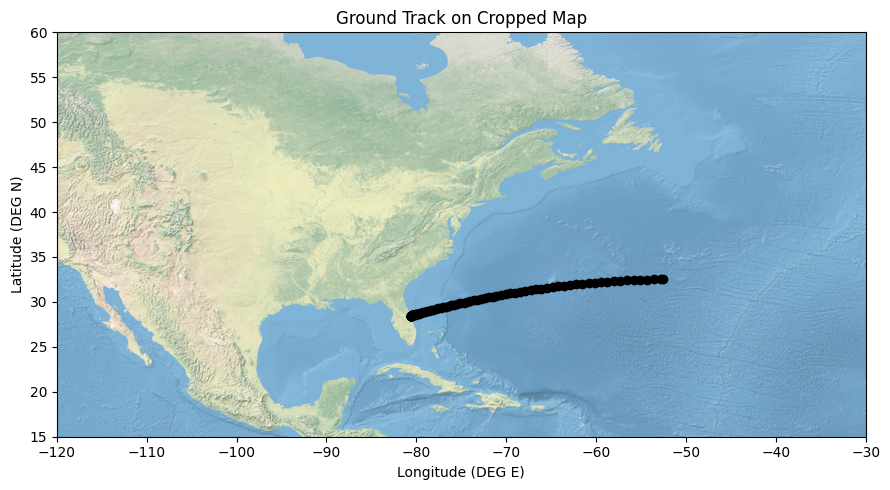

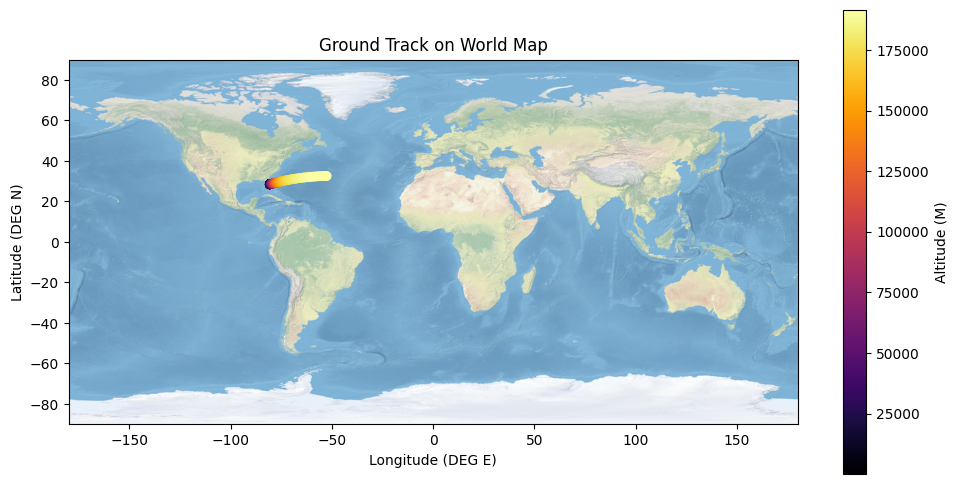

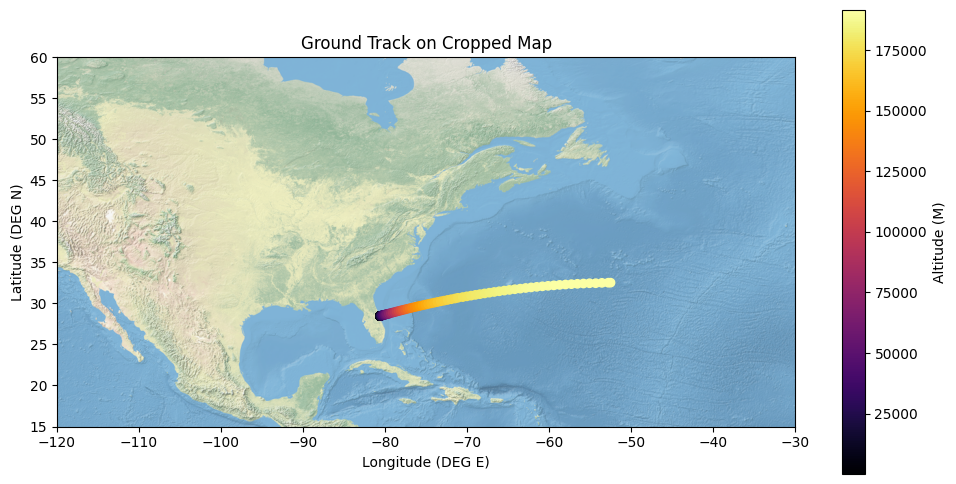

In [139]:
%run blastoff.py as-505-ascent-phase-data.txt

In [116]:
import numpy as np
import matplotlib.pyplot as plt

### Reading Text File

In [117]:
def parse_apollo(filename):

    data = {}  # dictionary for data arrays
    units = {}  # dictionary for units
    headings = None
    find_units = None

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("$") or line == "":
                continue # ignore

            # Creating lists to store each columns data
            if line.startswith("TIME"):
                headings = [i.strip() for i in line.split(",")]
                find_units = True
                continue

            # storing units for each columns
            
            if find_units:
                u_list = [u.strip() for u in line.split(",")]
                for i in range(len(headings)):
                    units[headings[i]] = u_list[i]

                for h in headings:
                    data[h] = []

                find_units = False 
                continue

            # Appedning each value to correct column
            if headings and "," in line:
                parts = [i.strip() for i in line.split(",")]
                if len(parts) == len(headings):
                    try:
                        # converting to floats
                        nums = list(map(float, parts))
                        for i in range(len(headings)):
                            column = headings[i]
                            value = nums[i]
                            data[column].append(value)
                    except ValueError:
                        #skipping rows without numeric data
                        pass

    # converting data
    for h in data:
        data[h] = np.array(data[h])

    return data, units

In [118]:
filename = 'as-505-ascent-phase-data.txt'
datas, units = parse_apollo(filename)
datas, units

({'TIME': array([0.0000e+00, 2.5000e-01, 5.3000e-01, 1.0000e+00, 2.0000e+00,
         3.0000e+00, 4.0000e+00, 5.0000e+00, 6.0000e+00, 7.0000e+00,
         8.0000e+00, 9.0000e+00, 1.0000e+01, 1.5000e+01, 2.0000e+01,
         2.5000e+01, 3.0000e+01, 3.5000e+01, 4.0000e+01, 4.5000e+01,
         5.0000e+01, 5.5000e+01, 6.0000e+01, 6.5000e+01, 7.0000e+01,
         7.5000e+01, 8.0000e+01, 8.5000e+01, 9.0000e+01, 9.5000e+01,
         1.0000e+02, 1.0500e+02, 1.1000e+02, 1.1500e+02, 1.2000e+02,
         1.2500e+02, 1.3000e+02, 1.3500e+02, 1.4000e+02, 1.4500e+02,
         1.5000e+02, 1.5500e+02, 1.6000e+02, 1.6400e+02, 1.7000e+02,
         1.8000e+02, 1.9000e+02, 2.0000e+02, 2.1000e+02, 2.2000e+02,
         2.3000e+02, 2.4000e+02, 2.5000e+02, 2.6000e+02, 2.7000e+02,
         2.8000e+02, 2.9000e+02, 3.0000e+02, 3.1000e+02, 3.2000e+02,
         3.3000e+02, 3.4000e+02, 3.5000e+02, 3.6000e+02, 3.7000e+02,
         3.8000e+02, 3.9000e+02, 4.0000e+02, 4.1000e+02, 4.2000e+02,
         4.3000e+02, 4.400

### Plotting Parameters

In [ ]:
def plot_parameters(data, units):
    time = data['TIME']
    for key in data:
        if key == 'TIME':
            continue
        plt.figure(figsize=(10,5))
        plt.plot(time, data[key])
        plt.xlabel("Time (s)")
        plt.ylabel(f'{key} ({units[key]})')
        plt.title(f"{key} vs Time")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

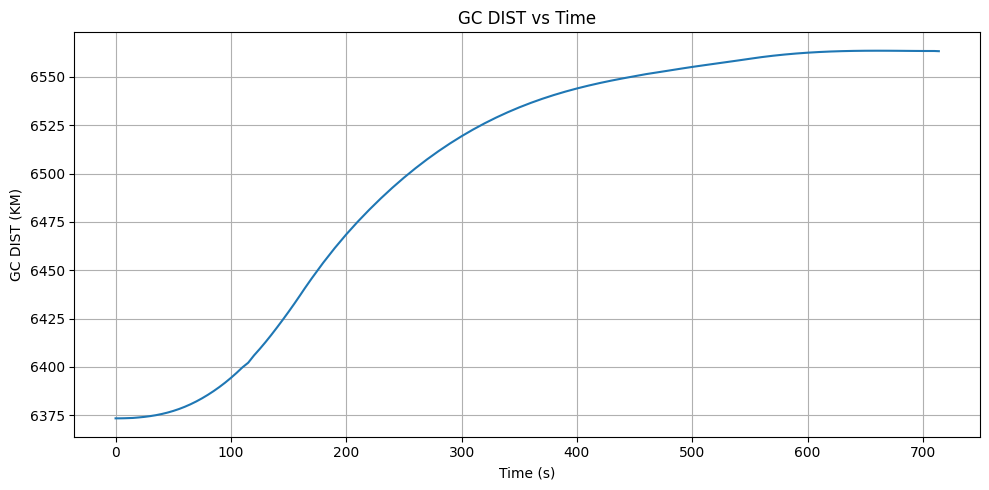

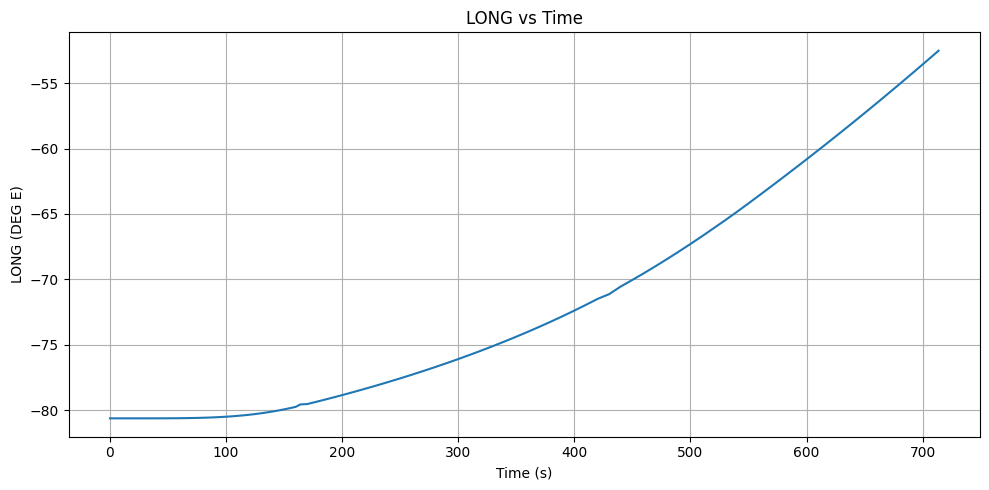

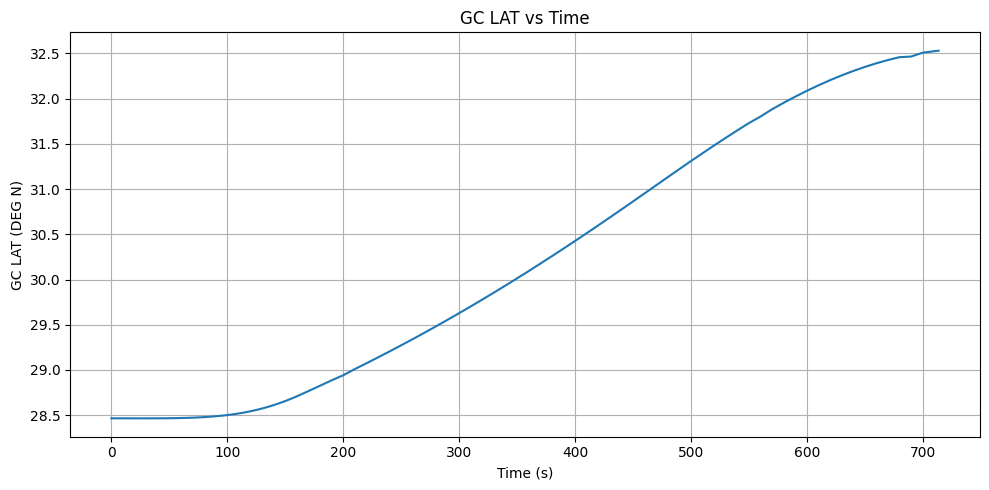

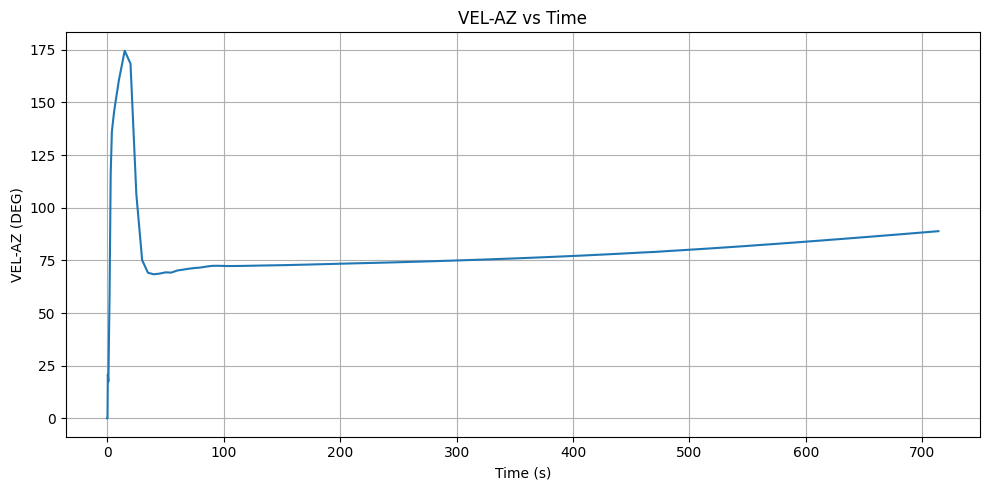

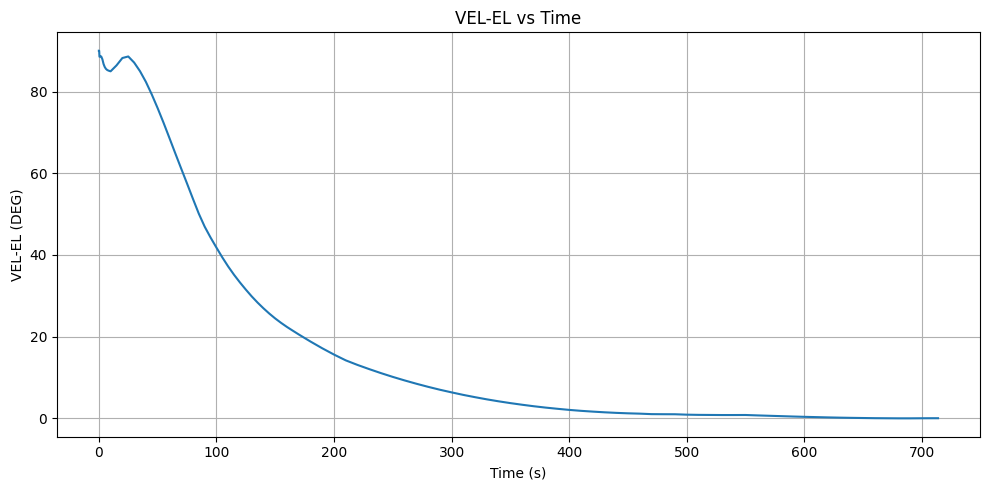

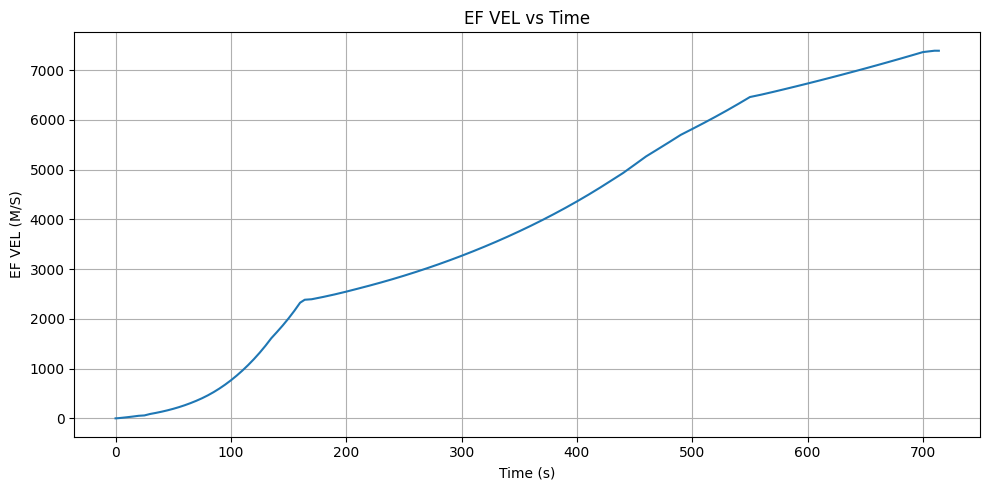

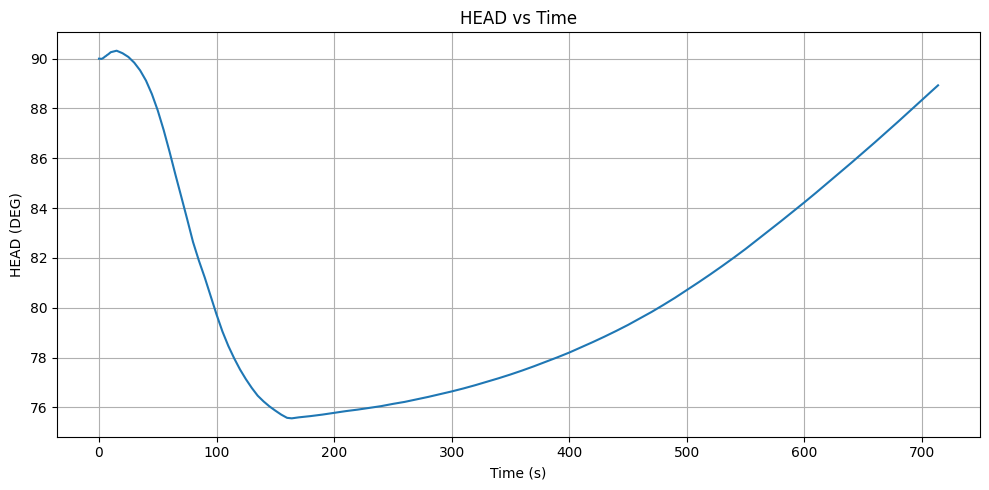

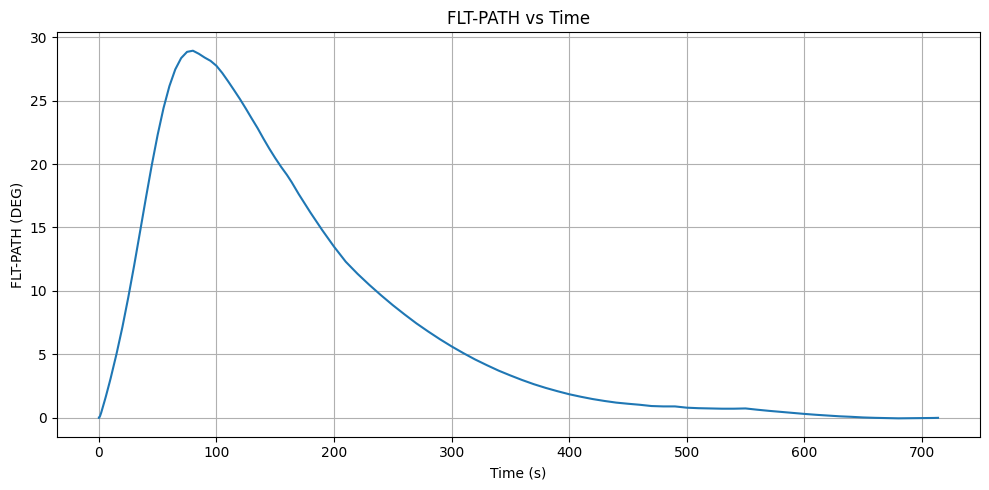

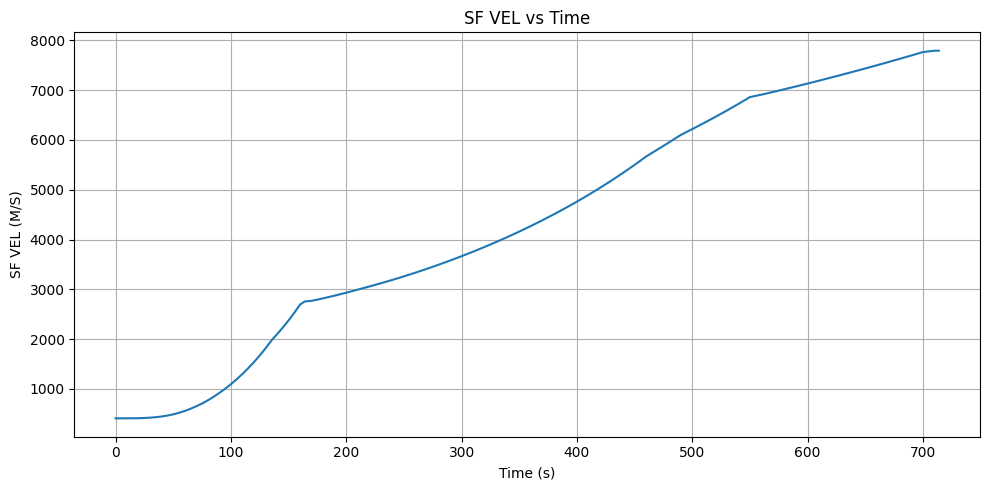

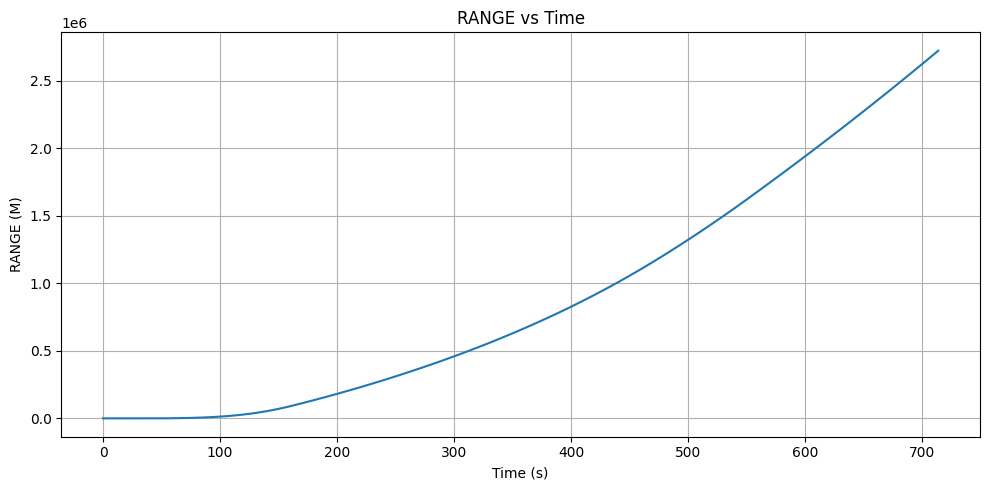

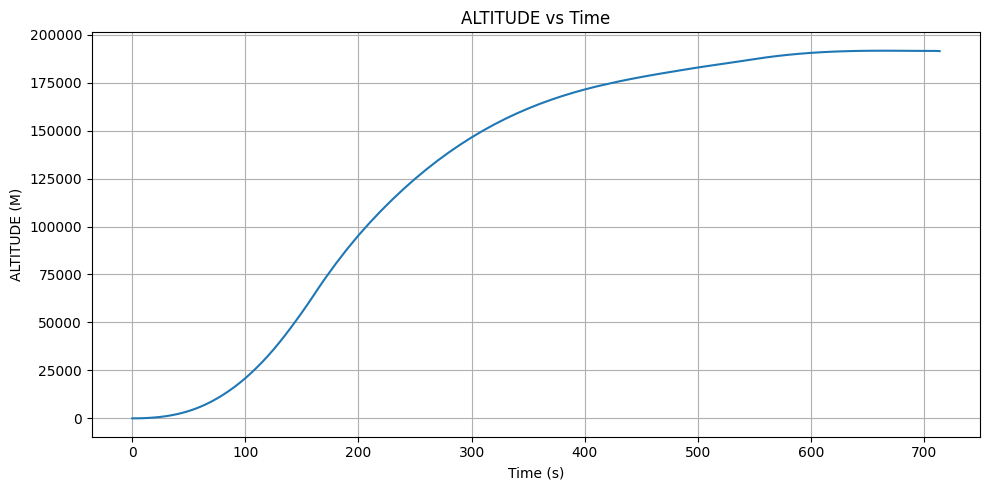

In [120]:
plot_parameters(datas, units)

### Plotting Groundtrack

In [121]:
def groundtrack(data, units):
    plt.figure(figsize=(10,5))
    plt.plot(data['LONG'], data['GC LAT'])
    plt.xlabel(f"Longitude ({units['LONG']})")
    plt.ylabel(f'Latitude ({units['GC LAT']})')
    plt.title('Apollo 10 Ground Track')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

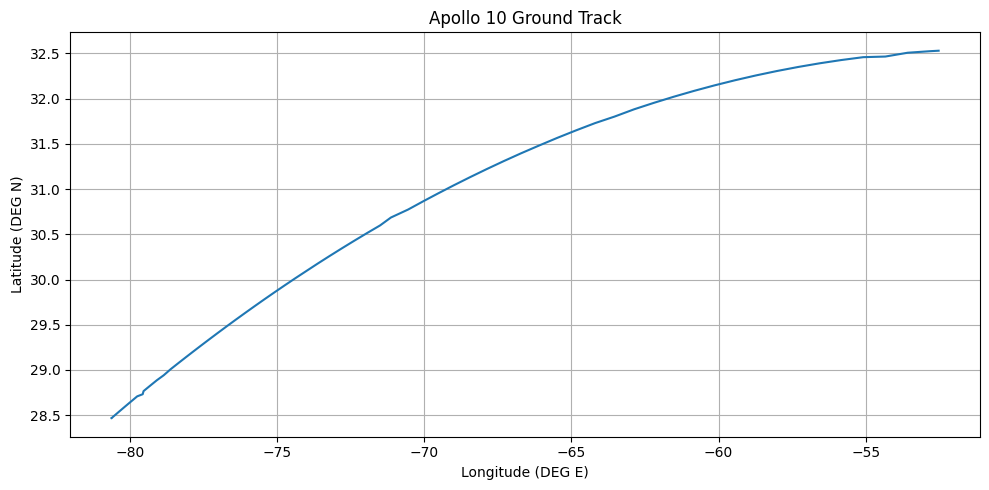

In [122]:
groundtrack(datas, units)

### Plotting Groundtrack on map

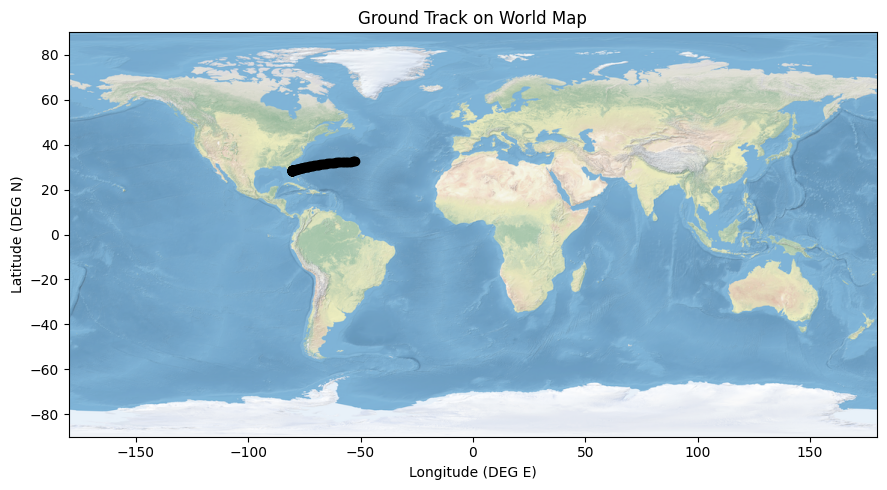

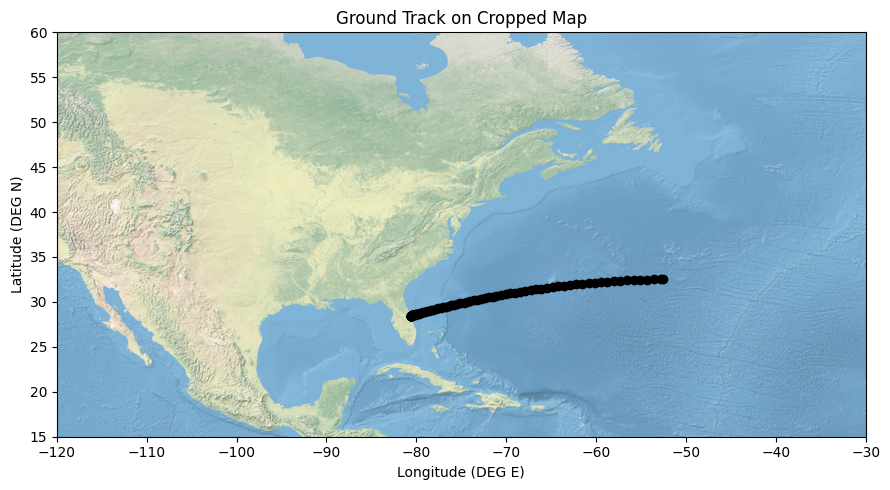

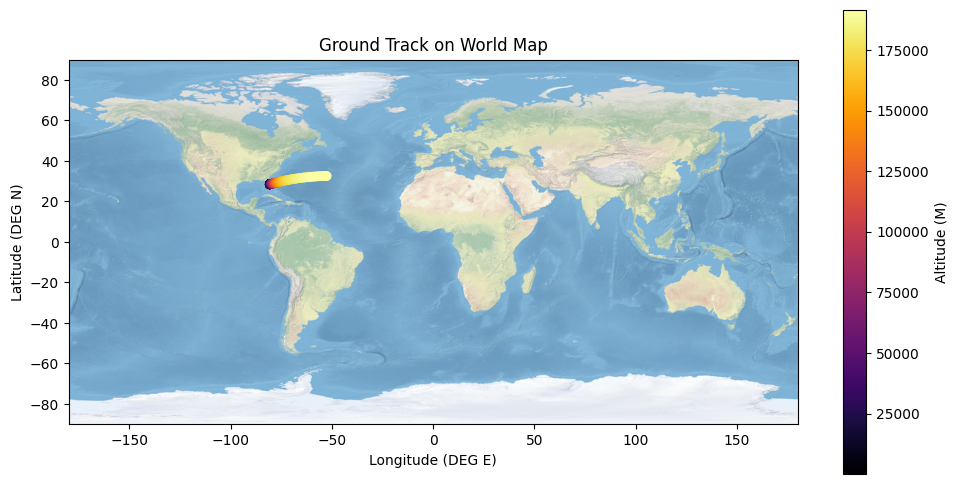

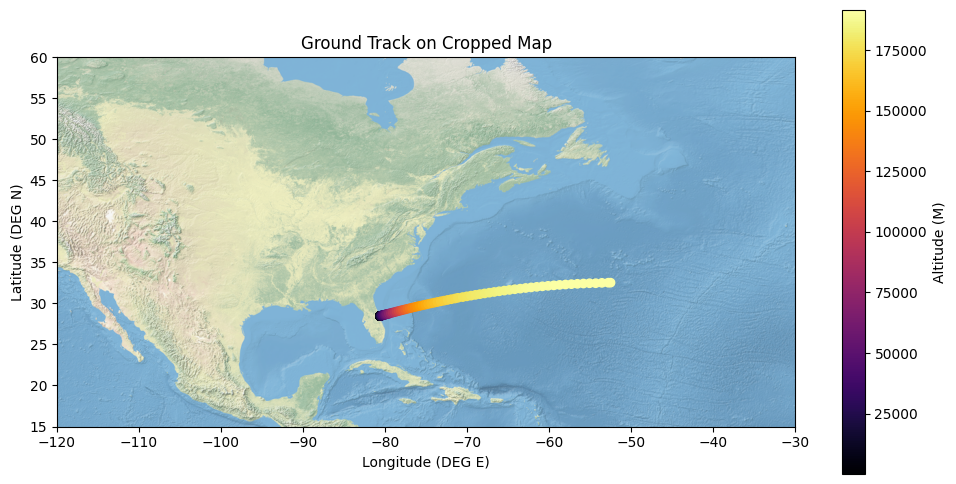

In [123]:
def groundtrack_map(data, units, altitude = False):
    def plot_map(im, extent, title):
        fig, ax = plt.subplots(figsize=(10,5))
        ax.set_aspect("equal")
        plt.imshow(plt.imread(im), extent=extent)
        if altitude:
            plot = plt.scatter(data['LONG'], data['GC LAT'], c=data['ALTITUDE'], cmap='inferno')
            plt.colorbar(plot, label= f'Altitude ({units['ALTITUDE']})')
        else:
            plt.scatter(data['LONG'], data['GC LAT'], color='black')
        plt.xlabel(f"Longitude ({units['LONG']})")
        plt.ylabel(f'Latitude ({units['GC LAT']})')
        plt.title(title)
        plt.tight_layout()

    plot_map(r'maps\NE1_50M_SR_W_1080.png', [-180, 180, -90, 90], 'Ground Track on World Map')
    plot_map(r'maps\NE1_50M_SR_W_CROPPED_1080.png', [-120, -30, 15, 60], 'Ground Track on Cropped Map')

groundtrack_map(datas, units)
groundtrack_map(datas, units, True)